# Observers, collectors, and analysis

{bdg-primary}`Multiple CUDA GPUs` {bdg-secondary}`256^3 particles` {bdg-success}`saved outputs`

Observers materialize one PyTree per integration time; collectors update caller-managed
state without storing every particle snapshot.  Both are forward-only analysis paths and
stay outside the custom N-body adjoint.  This notebook records normalized density
projections, collects a scalar displacement history, and computes the final differentiable
power spectrum.

```{admonition} Committed execution record
:class: note
All outputs and plots on this page are committed in the notebook; hosted documentation
does not execute them.  The first executed output is the environment and configuration
record for the published run.
```


In [1]:
%matplotlib inline
from importlib.metadata import version as distribution_version
from pathlib import Path
import pmpp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pmpp.cosmology import boltzmann
from pmpp import Configuration
from pmpp.cosmology import SimpleLCDM
from pmpp.initial_conditions import lpt
from pmpp.initial_conditions import linear_modes, white_noise
from pmpp import MultiGPUConfiguration
from pmpp.nbody import nbody_collect, nbody_observe
from pmpp.nbody.observers import density_projection_observer
from pmpp.analysis import density_to_pk
from pmpp.cic import scatter
from pmpp.distributed import create_compute_mesh

SEED = 5
RESOLUTION = 256
gpu_devices = [device for device in jax.devices() if device.platform == "gpu"]
if len(gpu_devices) < 2:
    raise RuntimeError("This precomputed simulation notebook requires at least two visible CUDA devices.")
package_origin = (
    "site-packages"
    if any(part in {"site-packages", "dist-packages"} for part in Path(pmpp.__file__).resolve().parts)
    else "source-tree"
)
execution_record = {
    "pmpp_version": distribution_version("pmpp"),
    "package_origin": package_origin,
    "jax_version": jax.__version__,
    "backend": jax.default_backend(),
    "selected_device_count": len(gpu_devices),
    "visible_device_count": len(jax.devices()),
    "selected_device_models": [device.device_kind for device in gpu_devices],
    "seed": SEED,
    "configuration": {
        "box_size_mpc_h": 100.0,
        "particle_grid": (RESOLUTION,) * 3,
        "mesh_ratio": 1,
        "a_start": 1 / 64,
        "a_stop": 1.0,
        "a_nbody_maxstep": 1 / 64,
        "observer_axis": 0,
        "mode": "mesh_halo",
    },
    "capacities": {
        "max_ptcl_per_slice": 10_066_329,
        "max_share_ptcl": 1_600_000,
        "max_halo_share_ptcl": 800_000,
        "max_share_gather_ptcl": 1_800_000,
    },
}
print("PM++ DOCUMENTATION EXECUTION RECORD")
for key, value in execution_record.items():
    print(f"{key}: {value}")
compute_mesh = create_compute_mesh(gpu_devices)
conf = Configuration(
    ptcl_spacing=100.0 / RESOLUTION,
    ptcl_grid_shape=(RESOLUTION,) * 3,
    mesh_shape=1,
    multigpu=MultiGPUConfiguration(compute_mesh=compute_mesh, mode="mesh_halo"),
    max_ptcl_per_slice=10_066_329,
    max_share_ptcl=1_600_000,
    max_halo_share_ptcl=800_000,
    max_share_gather_ptcl=1_800_000,
    a_start=1 / 64,
    a_stop=1.0,
    a_nbody_maxstep=1 / 64,
    float_dtype=jnp.float32,
)

print("observation scale factors:", np.asarray(conf.a_nbody))


PM++ DOCUMENTATION EXECUTION RECORD
pmpp_version: 0.1.6
package_origin: site-packages
jax_version: 0.6.2
backend: gpu
selected_device_count: 2
visible_device_count: 2
selected_device_models: ['NVIDIA GeForce RTX 3090', 'NVIDIA GeForce RTX 3090']
seed: 5
configuration: {'box_size_mpc_h': 100.0, 'particle_grid': (256, 256, 256), 'mesh_ratio': 1, 'a_start': 0.015625, 'a_stop': 1.0, 'a_nbody_maxstep': 0.015625, 'observer_axis': 0, 'mode': 'mesh_halo'}
capacities: {'max_ptcl_per_slice': 10066329, 'max_share_ptcl': 1600000, 'max_halo_share_ptcl': 800000, 'max_share_gather_ptcl': 1800000}


observation scale factors: [0.015625 0.03125  0.046875 0.0625   0.078125 0.09375  0.109375 0.125
 0.140625 0.15625  0.171875 0.1875   0.203125 0.21875  0.234375 0.25
 0.265625 0.28125  0.296875 0.3125   0.328125 0.34375  0.359375 0.375
 0.390625 0.40625  0.421875 0.4375   0.453125 0.46875  0.484375 0.5
 0.515625 0.53125  0.546875 0.5625   0.578125 0.59375  0.609375 0.625
 0.640625 0.65625  0.671875 0.6875   0.703125 0.71875  0.734375 0.75
 0.765625 0.78125  0.796875 0.8125   0.828125 0.84375  0.859375 0.875
 0.890625 0.90625  0.921875 0.9375   0.953125 0.96875  0.984375 1.      ]


## Stack projected-density observations

The observer scatters the current particles, sums along x, and normalizes each image by
its mean.  `include_start=True` returns one frame for every entry in `conf.a_nbody`.


In [2]:
projection_observer = density_projection_observer(axis=0, normalize=True)

def rms_displacement_collector(state, a_prev, a_next, particle_state, cosmo_state, conf_state):
    del a_prev, a_next, cosmo_state, conf_state
    values, index = state
    active = ~particle_state.unused_index
    squared = jnp.where(active[:, None], particle_state.disp**2, 0.0)
    rms = jnp.sqrt(jnp.sum(squared) / (jnp.sum(active) * particle_state.disp.shape[1]))
    return values.at[index].set(rms), index + 1

def full_analysis(seed):
    cosmo = boltzmann(SimpleLCDM(conf), conf)
    particles = lpt(linear_modes(white_noise(seed, conf), cosmo, conf), cosmo, conf)
    particles_final, frames = nbody_observe(
        particles,
        cosmo,
        conf,
        projection_observer,
        include_start=True,
        return_final=True,
    )
    initial_state = (
        jnp.zeros(len(conf.a_nbody) - 1, dtype=conf.float_dtype),
        jnp.asarray(0, dtype=jnp.int32),
    )
    rms_history, final_index = nbody_collect(
        particles,
        cosmo,
        conf,
        rms_displacement_collector,
        initial_state,
    )
    final_density = scatter(particles_final, conf)
    k, power, mode_counts = density_to_pk(final_density, conf, mas="CIC")
    return frames, rms_history, final_index, final_density, k, power, mode_counts

compiled_analysis = jax.jit(full_analysis)
frames, rms_history, final_index, final_density, k, power, mode_counts = compiled_analysis(SEED)
power.block_until_ready()

assert frames.shape == (len(conf.a_nbody), RESOLUTION, RESOLUTION)
np.testing.assert_allclose(np.asarray(frames).mean(axis=(1, 2)), 1.0, rtol=2e-5, atol=2e-5)
print("frame stack shape:", frames.shape)


frame stack shape: (64, 256, 256)


## Collect a compact scalar history

This collector carries `(values, index)` through the same integration but stores only the
RMS displacement after each interval.  Collector state and updates must be pure JAX
PyTrees so they can live inside `lax.scan`.


In [3]:
assert int(final_index) == len(conf.a_nbody) - 1
print("RMS displacement after each interval:", np.asarray(rms_history))


RMS displacement after each interval: [0.16509254 0.247373   0.32963714 0.4119401  0.4943177  0.57679814
 0.6594066  0.74216586 0.82509613 0.90821314 0.9915218  1.0749954
 1.1585791  1.2422135  1.3258282  1.4093282  1.4926078  1.5755403
 1.6580187  1.7399776  1.8213378  1.9019886  1.9818313  2.0607836
 2.138766   2.2157001  2.291539   2.366207   2.4395392  2.5113132
 2.5814817  2.6501067  2.7172015  2.7827559  2.8467896  2.9093504
 2.97048    3.030217   3.0885963  3.1456332  3.2012994  3.2555556
 3.3083546  3.359672   3.4094906  3.457806   3.5046463  3.5500329
 3.594005   3.6366308  3.6779907  3.7181618  3.757203   3.7951589
 3.8320684  3.8679676  3.9028866  3.936849   3.9698763  4.0019875
 4.0332003  4.0635333  4.0930033 ]


## Final density and isotropic power spectrum

`density_to_pk` converts density to overdensity internally and returns shell centers,
shell-averaged power, and mode counts.  Because it is written in JAX, the statistic can
also appear inside differentiable objectives.


In [4]:
analysis_summary = {
    "density_mean": float(final_density.mean()),
    "power_bins": int(k.size),
    "minimum_modes_per_bin": int(mode_counts.min()),
    "maximum_modes_per_bin": int(mode_counts.max()),
}
analysis_summary


{'density_mean': 1.0,
 'power_bins': 221,
 'minimum_modes_per_bin': 7,
 'maximum_modes_per_bin': 205074}

selected observer scale factors: [0.015625 0.09375  1.      ]


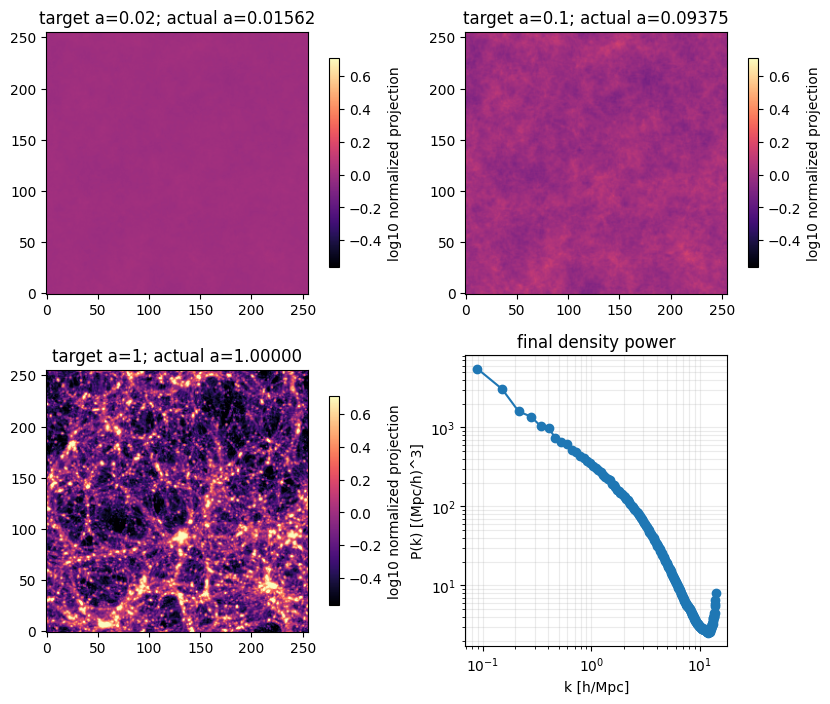

In [5]:
frames_host = np.asarray(frames)
requested_scale_factors = np.asarray((0.02, 0.1, 1.0))
schedule = np.asarray(conf.a_nbody)
selected_indices = [int(np.argmin(np.abs(schedule - target))) for target in requested_scale_factors]
print("selected observer scale factors:", schedule[selected_indices])
selected_log_frames = [
    np.log10(np.clip(frames_host[index], 1e-6, None))
    for index in selected_indices
]
all_log_values = np.concatenate([frame.ravel() for frame in selected_log_frames])
vmin, vmax = np.percentile(all_log_values, (0.5, 99.5))

fig, axes = plt.subplots(2, 2, figsize=(8.2, 7.0), constrained_layout=True)
for target, index, log_frame, ax in zip(
    requested_scale_factors,
    selected_indices,
    selected_log_frames,
    axes.flat[:3],
):
    image = ax.imshow(log_frame, origin="lower", cmap="magma", vmin=vmin, vmax=vmax)
    ax.set_title(f"target a={target:g}; actual a={schedule[index]:.5f}")
    fig.colorbar(image, ax=ax, shrink=0.72, label="log10 normalized projection")

axes[1, 1].loglog(np.asarray(k), np.asarray(power), "o-")
axes[1, 1].set_xlabel("k [h/Mpc]")
axes[1, 1].set_ylabel("P(k) [(Mpc/h)^3]")
axes[1, 1].set_title("final density power")
axes[1, 1].grid(alpha=0.25, which="both")
plt.show()
